In [2]:
import pandas as pd
import numpy as np
import re #data cleaning
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords      # to remove unnecessary words
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

In [3]:
#download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
data = {
    "Review" : [
        "The product quality is excellent and delivery was very fast",
        "Very bad packaging and the item was damaged",
        "Customer service was helpful and responsive",
        "The delivery was delayed and support team did not respond",
        "Amazing product",
        "Poor quality",
        "fast shipping",
        "the product stopped working after 2 days",
        "Excellent service",
        "Late delivery"
    ]
}

df = pd.DataFrame(data)

print("Customer review dataset")
df.head()

Customer review dataset


,Review
0,The product quality is excellent and delivery ...
1,Very bad packaging and the item was damaged
2,Customer service was helpful and responsive
3,The delivery was delayed and support team did ...
4,Amazing product


In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text) #remove spevial characters and numbers

    #tokenization
    words = word_tokenize(text)
    print('tokenizer',words)

    #remove stopwords
    words = [word for word in words if word not in stop_words]
    print('without stopwords', words)

    #joins words again
    cleaned_text = " ".join(words)

    return cleaned_text

df['Cleaned_Review'] = df['Review'].apply(clean_text)

print("\nCleaned review dataset")
print(df[['Review','Cleaned_Review']])





tokenizer ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
without stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
tokenizer ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
without stopwords ['bad', 'packaging', 'item', 'damaged']
tokenizer ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
without stopwords ['customer', 'service', 'helpful', 'responsive']
tokenizer ['the', 'delivery', 'was', 'delayed', 'and', 'support', 'team', 'did', 'not', 'respond']
without stopwords ['delivery', 'delayed', 'support', 'team', 'respond']
tokenizer ['amazing', 'product']
without stopwords ['amazing', 'product']
tokenizer ['poor', 'quality']
without stopwords ['poor', 'quality']
tokenizer ['fast', 'shipping']
without stopwords ['fast', 'shipping']
tokenizer ['the', 'product', 'stopped', 'working', 'after', 'days']
without stopwords ['product', 'stopped', 'working', 'days']
tokenizer ['excellent', 'service']
wi

In [7]:
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score['compound']

  if compound >= 0.05:
    return 'Positive'
  elif compound <= -0.05:
    return 'Negative'
  else:
    return 'Neutral'

df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)

print("\nSentiment Analysis Results")
print(df[['Review','Sentiment']])



Sentiment Analysis Results
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1        Very bad packaging and the item was damaged  Negative
2        Customer service was helpful and responsive  Positive
3  The delivery was delayed and support team did ...  Positive
4                                    Amazing product  Positive
5                                       Poor quality  Negative
6                                      fast shipping   Neutral
7           the product stopped working after 2 days  Negative
8                                  Excellent service  Positive
9                                      Late delivery   Neutral


In [10]:
all_words = " ".join(df['Cleaned_Review'])

word_list = all_words.split()
word_freq = Counter(word_list)

#display top 10 keywords
print("\nTop 10 Keywords")
print(word_freq.most_common(10))



Top 10 Keywords
[('product', 3), ('delivery', 3), ('quality', 2), ('excellent', 2), ('fast', 2), ('service', 2), ('bad', 1), ('packaging', 1), ('item', 1), ('damaged', 1)]


In [11]:
negative_reviews = df[df['Sentiment'] == 'Negative']

negative_words = " ".join(negative_reviews['Cleaned_Review'])

negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)

print("\nMost common complaint keywords:")
print(complaint_freq.most_common(10))


Most common complaint keywords:
[('bad', 1), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('product', 1), ('stopped', 1), ('working', 1), ('days', 1)]


In [13]:
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts

,count
Sentiment,
Positive,5
Negative,3
Neutral,2


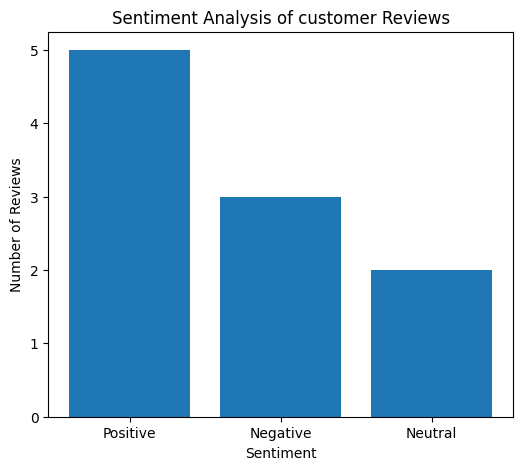

In [14]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('Sentiment Analysis of customer Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


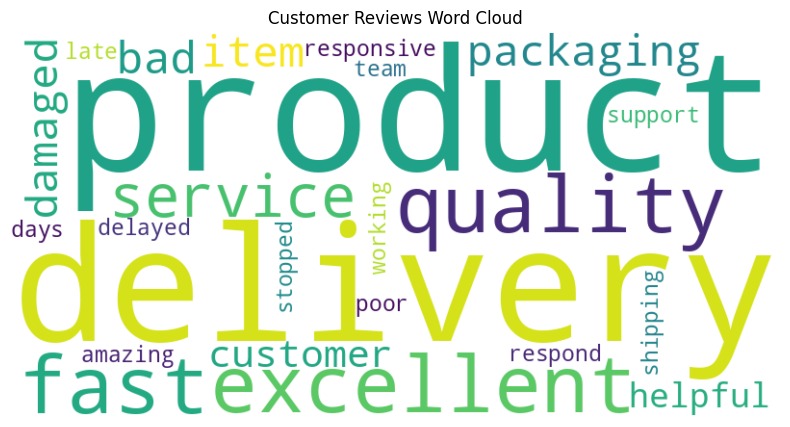

In [15]:
wordcloud = WordCloud(width=800,
                      height=400,
                      background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear') #imshow means image show
plt.axis('off')
plt.title('Customer Reviews Word Cloud')
plt.show()

In [16]:
print("\nBusiness Insights")
print("---------------------------------------------")

positive_count = len(df[df['Sentiment'] == 'Positive'])
negative_count = len(df[df['Sentiment'] == 'Negative'])

print("Total Positive Reviews :", positive_count)
print("Total Negative Reviews :", negative_count)

print("\nCommon Positive Areas: ")
print("- Product quality")
print("- Fast Delivery")
print("- Good Customer service")

print("\nCommon customer complaints; ")
print("- Delayed Delivery")
print("- Damaged Products")
print("- Bad Customer service")




Business Insights
---------------------------------------------
Total Positive Reviews : 5
Total Negative Reviews : 3

Common Positive Areas: 
- Product quality
- Fast Delivery
- Good Customer service

Common customer complaints; 
- Delayed Delivery
- Damaged Products
- Bad Customer service
